In [1]:
import urllib.request
import os

import json
import pandas as pd
import matplotlib.pyplot as plt

## Downloading dataset

In [ ]:

os.makedirs("../data", exist_ok=True)

print("Downloading reviews... (this may take 2-3 minutes)")
urllib.request.urlretrieve(
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl",
    "data/All_Beauty.jsonl"
)
print("Reviews done!")

print("Downloading metadata...")
urllib.request.urlretrieve(
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_All_Beauty.jsonl",
    "data/meta_All_Beauty.jsonl"
)
print("Metadata done!")

print("Both files downloaded successfully")

Reviews done!
Metadata done!
Both files downloaded successfully


## Merging both dataset

In [2]:
# Load reviews
df_reviews = pd.read_json("../data/All_Beauty.jsonl", lines=True)

# Load product metadata
df_meta = pd.read_json("../data/meta_All_Beauty.jsonl", lines=True)

In [3]:
print("Reviews DataFrame:")
print(df_reviews.shape)
print(df_reviews.columns.tolist())

print("\nMetadata DataFrame:")
print(df_meta.shape)
print(df_meta.columns.tolist())

Reviews DataFrame:
(701528, 10)
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Metadata DataFrame:
(112590, 14)
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


In [21]:
df = df_reviews.merge(
    df_meta[["parent_asin", "title", "description", "price", "average_rating"]],
    on="parent_asin",
    how="left"
)

print("Merged shape:", df.shape)
print(df.columns.tolist())
df.to_csv("../data/amazon_beauty_merged.csv", index=False)
print("Saved!")

Merged shape: (701528, 14)
['rating', 'title_x', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'title_y', 'description', 'price', 'average_rating']
Saved!


## Loading dataset and Performing EDA

In [6]:
data = pd.read_csv("../data/amazon_beauty_merged.csv")

In [8]:
data.head()

,rating,title_x,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,title_y,description,price,average_rating
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True,Herbivore - Natural Sea Mist Texturizing Salt ...,"['If given the choice, weÕd leave most telltal...",NaN,4.3
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True,All Natural Vegan Dry Shampoo Powder - Eco Fri...,[],NaN,4.0
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True,New Road Beauty - Creamsicle - Variety 3 Pack ...,['New Road Beauty Paraffin Wax is recommended ...,21.98,4.4
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True,muaowig Ombre Body Wave Bundles 1B Grey Human ...,"[""Hair Material: Brazilian Virgin Human Hair B...",NaN,1.0
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True,Yinhua Electric Nail Drill Kit Portable Profes...,[],NaN,3.5


In [3]:
data.shape

(701528, 14)

In [30]:
print(data.columns.tolist())

['rating', 'title_x', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'title_y', 'description', 'price', 'average_rating', 'year', 'text_len']


In [4]:
data.dtypes

rating                 int64
title_x               object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp             object
helpful_vote           int64
verified_purchase       bool
title_y               object
description           object
price                float64
average_rating       float64
dtype: object

In [9]:
data.isnull().sum()

rating                    0
title_x                 160
text                    212
images                    0
asin                      0
parent_asin               0
user_id                   0
timestamp                 0
helpful_vote              0
verified_purchase         0
title_y                  84
description               0
price                515905
average_rating            0
dtype: int64

In [19]:
data.duplicated().sum()

np.int64(7275)

In [21]:
data['rating'].describe()

count    701528.000000
mean          3.960245
std           1.494452
min           1.000000
25%           3.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

In [26]:
data["text_len"] = data["text"].str.len()
data["text_len"].describe()

count    701316.000000
mean        173.083476
std         246.943960
min           1.000000
25%          44.000000
50%         102.000000
75%         209.000000
max       14989.000000
Name: text_len, dtype: float64

In [33]:
print("Unique users:", data["user_id"].nunique())

Unique users: 631986


In [34]:
print("Unique products:", data["parent_asin"].nunique())

Unique products: 112565


In [35]:
user_counts = data.groupby("user_id").size()
print("Users with <5 reviews:", (user_counts < 5).sum() / len(user_counts) * 100, "%")

Users with <5 reviews: 99.74366520777359 %


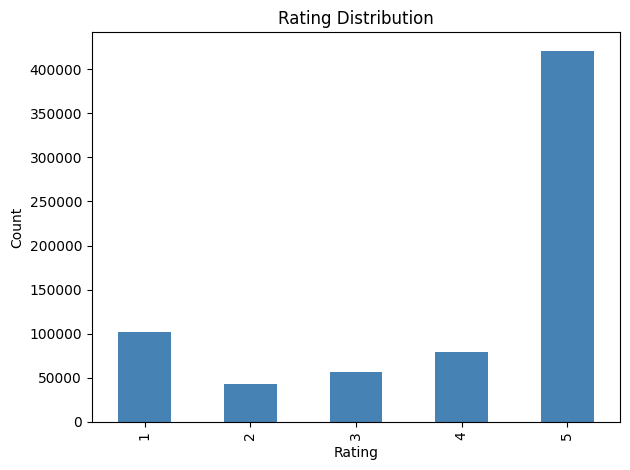

rating
5    0.599728
1    0.145511
4    0.113154
3    0.080263
2    0.061343
Name: proportion, dtype: float64


In [ ]:
data["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(data["rating"].value_counts(normalize=True))

In [14]:
user_activity = data.groupby("user_id").size()
print("Reviews per user:")
print(user_activity.describe())
print(f"\nUsers with only 1 review: {(user_activity == 1).sum()}")
print(f"Users with 10+ reviews: {(user_activity >= 10).sum()}")

Reviews per user:
count    631986.000000
mean          1.110037
std           0.753202
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         165.000000
dtype: float64

Users with only 1 review: 583553
Users with 10+ reviews: 330


In [15]:
product_popularity = data.groupby("parent_asin").size()
print("Reviews per product:")
print(product_popularity.describe())
print(f"\nProducts with only 1 review: {(product_popularity == 1).sum()}")
print(f"Products with 10+ reviews: {(product_popularity >= 10).sum()}")

Reviews per product:
count    112565.000000
mean          6.232204
std          25.189840
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1962.000000
dtype: float64

Products with only 1 review: 47566
Products with 10+ reviews: 13257


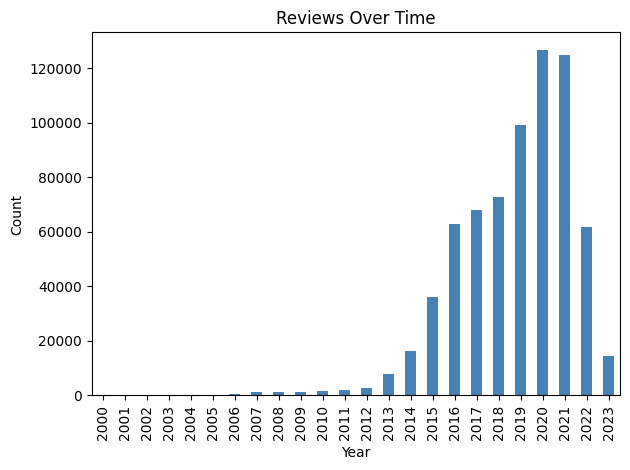

In [ ]:
data["timestamp"] = pd.to_datetime(data["timestamp"])
data["year"] = data["timestamp"].dt.year

data.groupby("year").size().plot(kind="bar", color="steelblue")
plt.title("Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [31]:
data["review_length"] = data["text"].fillna("").apply(len)
print(data["review_length"].describe())

count    701528.000000
mean        173.031171
std         246.924971
min           0.000000
25%          44.000000
50%         102.000000
75%         209.000000
max       14989.000000
Name: review_length, dtype: float64
